In [2]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_1500_clean.csv')
df.head()

,Emotion,Sentence,emotion_vn,source_example_idx,source_example
0,Other,cho mình xin bài nhạc tên là gì với ạ,khác,NaN,NaN
1,Disgust,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,khó chịu,NaN,NaN
2,Disgust,lo học đi . yêu đương lol gì hay lại thích học...,khó chịu,NaN,NaN
3,Enjoyment,uớc gì sau này về già vẫn có thể như cụ này :)),vui vẻ,NaN,NaN
4,Enjoyment,mỗi lần có video của con là cứ coi đi coi lại ...,vui vẻ,NaN,NaN


In [3]:
# Filter to get only augmented data (rows where source_example_idx is not NaN)
df_augmented = df[df['source_example_idx'].notna()].copy()

print(f"Total rows in dataset: {len(df)}")
print(f"Augmented rows: {len(df_augmented)}")
print(f"Original rows: {len(df) - len(df_augmented)}")

df_augmented.head()


Total rows in dataset: 10558
Augmented rows: 5004
Original rows: 5554


,Emotion,Sentence,emotion_vn,source_example_idx,source_example
5548,Anger,"Tức cái lồng ngực, bảo đi tìm người khác mà cò...",giận dữ,1.0,per đu ̣ me ̣ như 1 tro ̀ đu ̀ anh =))))) đi g...
5549,Anger,Vô lý hết sức!,giận dữ,2.0,như lol
5550,Anger,"ĐM, hả hê cái nỗi gì khi biết chuyện như thế này?",giận dữ,3.0,đcm hả hê cái lol gì chuyện này cơ chứ
5551,Anger,"Trời ơi, tức muốn bùng nổ luôn á trời! Cái kiể...",giận dữ,1.0,per đu ̣ me ̣ như 1 tro ̀ đu ̀ anh =))))) đi g...
5552,Anger,Thật là vớ vẩn hết chỗ nói!,giận dữ,2.0,như lol


In [4]:
# Export augmented data to CSV
df_augmented.to_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/augmented_1500_data.csv', index=False)
print(f"Exported {len(df_augmented)} augmented rows to augmented_data.csv")


Exported 5004 augmented rows to augmented_data.csv


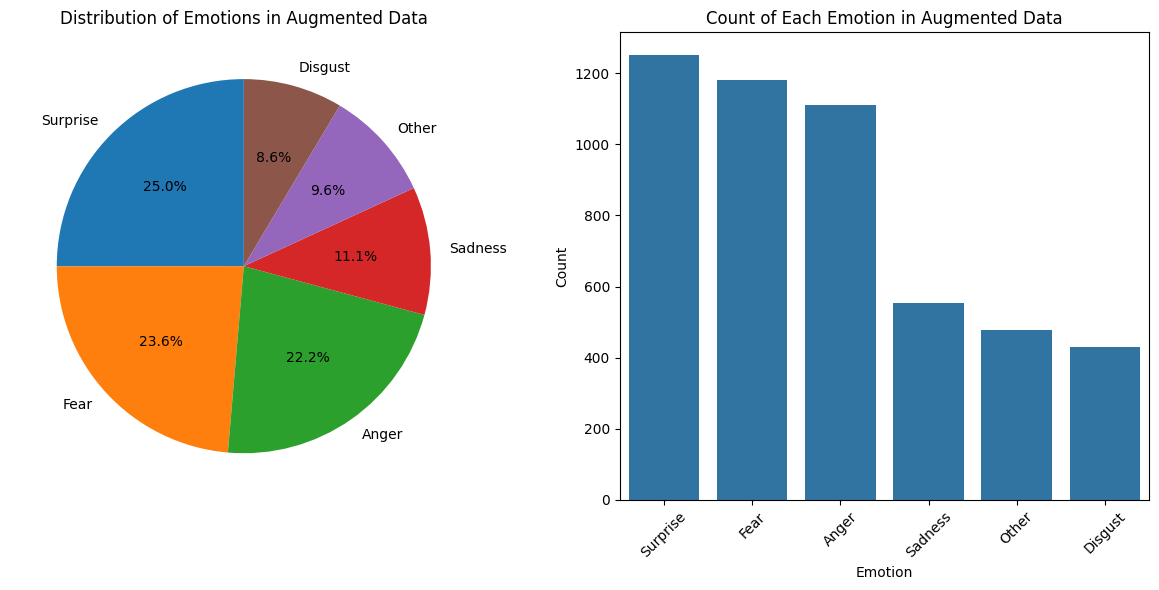


Emotion distribution in augmented data:
Emotion
Surprise    1252
Fear        1182
Anger       1109
Sadness      553
Other        479
Disgust      429
Name: count, dtype: int64

Total augmented samples: 5004


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of emotions in augmented data
plt.figure(figsize=(12, 6))

# Count plot for emotion distribution
plt.subplot(1, 2, 1)
emotion_counts = df_augmented['Emotion'].value_counts()
plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Emotions in Augmented Data')

plt.subplot(1, 2, 2)
sns.countplot(data=df_augmented, x='Emotion', order=emotion_counts.index)
plt.title('Count of Each Emotion in Augmented Data')
plt.xticks(rotation=45)
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Print statistics
print("\nEmotion distribution in augmented data:")
print(emotion_counts)
print(f"\nTotal augmented samples: {len(df_augmented)}")


Distribution of emotions in full dataset:
Emotion
Enjoyment    1558
Other        1500
Disgust      1500
Anger        1500
Surprise     1500
Sadness      1500
Fear         1500
Name: count, dtype: int64

Total samples in full dataset: 10558


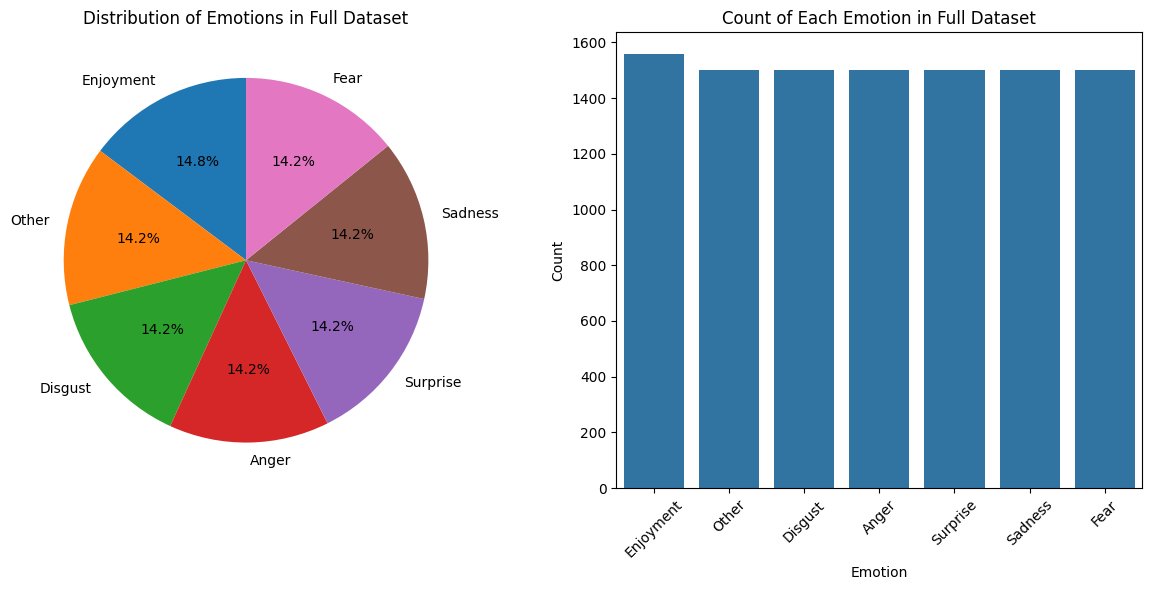


Comparison of original vs augmented data:
Original data samples: 5554
Augmented data samples: 5004
Total samples: 10558
Percentage augmented: 47.4%


In [6]:
# Print distribution of the full dataset
print("Distribution of emotions in full dataset:")
print(df['Emotion'].value_counts())
print(f"\nTotal samples in full dataset: {len(df)}")

# Create visualization for full dataset distribution
plt.figure(figsize=(12, 6))

# Count plot for emotion distribution in full dataset
plt.subplot(1, 2, 1)
emotion_counts_full = df['Emotion'].value_counts()
plt.pie(emotion_counts_full.values, labels=emotion_counts_full.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Emotions in Full Dataset')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Emotion', order=emotion_counts_full.index)
plt.title('Count of Each Emotion in Full Dataset')
plt.xticks(rotation=45)
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Compare original vs augmented data
print("\nComparison of original vs augmented data:")
print(f"Original data samples: {len(df) - len(df_augmented)}")
print(f"Augmented data samples: {len(df_augmented)}")
print(f"Total samples: {len(df)}")
print(f"Percentage augmented: {(len(df_augmented) / len(df)) * 100:.1f}%")


In [3]:
test_df = pd.read_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/test_gen_final.csv')
# Keep only the required columns
test_df = test_df[['Sentence_clean', 'emotion_vn']]
print("Test dataset columns after filtering:")
print(test_df.columns.tolist())
print(f"\nTest dataset shape: {test_df.shape}")
print("\nFirst few rows:")
print(test_df.head())


Test dataset columns after filtering:
['Sentence_clean', 'emotion_vn']

Test dataset shape: (955, 2)

First few rows:
                                      Sentence_clean emotion_vn
0  lúc trước chạy xe đạp đi ngang qua đàn vịt có ...     sợ hãi
1                                   cười ỉa cười lớn     vui vẻ
2  mày bị ngu hay sao mà viết bậy chỗ này chỗ kia...    giận dữ
3             giáo viên giờ đầy, thay người khác đi.    giận dữ
4  per khi ế nhưng vẫn phải giương mắt nhìn bọn n...       buồn


In [4]:
# Export test dataset to CSV
test_df.to_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/test_gen_final_filtered.csv', index=False)
print("Test dataset exported to test_gen_final_filtered.csv")


Test dataset exported to test_gen_final_filtered.csv


In [ ]:
# Load train, test, and validation datasets
train_df = pd.read_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_org_processed.csv')
test_df = pd.read_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/test_processed.csv')
val_df = pd.read_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/val_processed.csv')

print("Original dataset sizes:")
print(f"Train: {len(train_df)} samples")
print(f"Test: {len(test_df)} samples")
print(f"Validation: {len(val_df)} samples")

# Drop rows with emotion 'khác' from all datasets
train_df = train_df[train_df['emotion_vn'] != 'khác']
test_df = test_df[test_df['emotion_vn'] != 'khác']
val_df = val_df[val_df['emotion_vn'] != 'khác']

print("\nDataset sizes after removing 'khác' emotion:")
print(f"Train: {len(train_df)} samples")
print(f"Test: {len(test_df)} samples")
print(f"Validation: {len(val_df)} samples")

# Display emotion distribution for each dataset
print("\nEmotion distribution in train dataset:")
print(train_df['emotion_vn'].value_counts())

print("\nEmotion distribution in test dataset:")
print(test_df['emotion_vn'].value_counts())

print("\nEmotion distribution in validation dataset:")
print(val_df['emotion_vn'].value_counts())
